<a href="https://colab.research.google.com/github/10dimensions/rl-notebooks/blob/main/cliffwalking_qlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy matplotlib gymnasium

In [5]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# ==========================================
# 1. Hyperparameters & Initialization
# ==========================================
env = gym.make('CliffWalking-v1')

# Q-table: (number of states, number of actions)
n_states = env.observation_space.n
n_actions = env.action_space.n
Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.5          # Learning rate (0.5 is standard for CliffWalking for fast convergence)
gamma = 0.99         # Discount factor
num_episodes = 500   # Number of training episodes

# Epsilon-greedy parameters
epsilon = 1.0        # Start with 100% exploration
epsilon_min = 0.01   # Minimum exploration (1% random actions)
epsilon_decay = 0.99 # Decay rate per episode

# To track learning progress
episode_rewards = []



In [8]:
# ==========================================
# 2. Training Loop (Q-Learning)
# ==========================================
print("Starting Q-Learning training...")

for episode in range(num_episodes):
    # Reset environment (gymnasium returns state and info)
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # --- Epsilon-Greedy Action Selection ---
        if np.random.uniform() < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = np.argmax(Q[state, :])    # Exploit

        # Take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # --- Q-Learning Update ---
        # If the episode is over (terminated), there is no next state to bootstrap from
        if terminated:
            td_target = reward
        else:
            td_target = reward + gamma * np.max(Q[next_state, :])

        # Calculate TD error and update Q-value
        td_error = td_target - Q[state, action]
        Q[state, action] += alpha * td_error

        # Move to next state
        state = next_state
        total_reward += reward

    # Record reward and decay epsilon
    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training complete!\n")

Starting Q-Learning training...
Training complete!



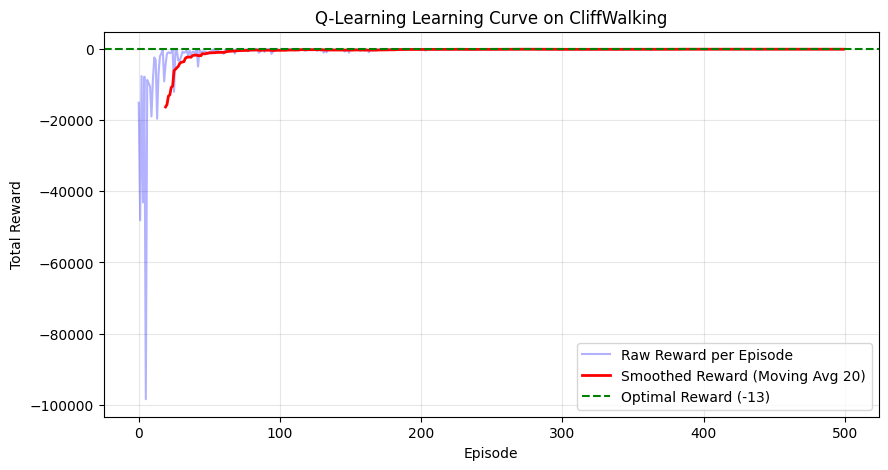

In [9]:
# ==========================================
# 3. Plot Learning Curve
# ==========================================
plt.figure(figsize=(10, 5))

# Calculate moving average for a smoother curve
window_size = 20
smoothed_rewards = np.convolve(episode_rewards, np.ones(window_size)/window_size, mode='valid')

plt.plot(episode_rewards, alpha=0.3, color='blue', label='Raw Reward per Episode')
plt.plot(range(window_size - 1, num_episodes), smoothed_rewards, color='red', linewidth=2, label=f'Smoothed Reward (Moving Avg {window_size})')

plt.axhline(y=-13, color='green', linestyle='--', label='Optimal Reward (-13)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Q-Learning Learning Curve on CliffWalking')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# ==========================================
# 4. Visualize the Learned Policy
# ==========================================
def visualize_policy(Q, env):
    """Prints the optimal policy derived from the Q-table."""
    grid_width = 12
    grid_height = 4
    arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}

    print("Learned Optimal Policy:")
    print("S = Start, G = Goal, C = Cliff")

    for row in range(grid_height):
        row_str = ""
        for col in range(grid_width):
            state = row * grid_width + col

            if row == 3 and col == 0:
                row_str += " S "
            elif row == 3 and col == 11:
                row_str += " G "
            elif row == 3 and 0 < col < 11:
                row_str += " C "
            else:
                best_action = np.argmax(Q[state, :])
                row_str += f" {arrows[best_action]} "
        print(row_str)

In [11]:
visualize_policy(Q, env)

Learned Optimal Policy:
S = Start, G = Goal, C = Cliff
 ↓  →  →  →  →  ↓  →  ↓  →  ↓  ↓  ↓ 
 →  →  ↓  →  →  →  →  ↓  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 
